In [1]:
import sys
print(sys.executable)

c:\ai chatbot\.venv\Scripts\python.exe


In [33]:
image_path = r"../assets/test_images/R.jpg"

In [31]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Main folders
ASSETS_DIR = PROJECT_ROOT / "assets"
TEST_IMAGES_DIR = ASSETS_DIR / "test_images"

MODEL_DIR = PROJECT_ROOT / "model"
RESULTS_DIR = PROJECT_ROOT / "results"

# Create folders if they don't exist
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# X-ray
IMAGE_PATH = TEST_IMAGES_DIR / "R.jpg"

# Models
CNN_MODEL_PATH = MODEL_DIR / "chest_xray_cnn.pth"
RESNET_MODEL_PATH = MODEL_DIR / "chest_xray_resnet18.pth"

print("Project:", PROJECT_ROOT)
print("Image:", IMAGE_PATH)
print("CNN:", CNN_MODEL_PATH)
print("ResNet:", RESNET_MODEL_PATH)

Project: c:\ai chatbot
Image: c:\ai chatbot\assets\test_images\R.jpg
CNN: c:\ai chatbot\model\chest_xray_cnn.pth
ResNet: c:\ai chatbot\model\chest_xray_resnet18.pth


In [2]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\ai chatbot\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [32]:
import shutil

old_resnet = PROJECT_ROOT / "models" / "chest_xray_resnet18.pth"

if old_resnet.exists():
    shutil.move(
        str(old_resnet),
        str(RESNET_MODEL_PATH)
    )
    print("ResNet moved to:", RESNET_MODEL_PATH)
else:
    print("ResNet already in correct location or not found.")

ResNet already in correct location or not found.


In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Path to dataset files:", path)

c:\ai chatbot\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\ACER\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [4]:
import kagglehub
print(kagglehub.__version__)

1.0.2


In [5]:
import os

print(os.listdir(path))

['chest_xray']


In [6]:
import os

dataset_path = os.path.join(path, "chest_xray")

print(os.listdir(dataset_path))

['chest_xray', 'test', 'train', 'val', '__MACOSX']


In [7]:
import os

for folder in ["train", "test", "val"]:
    folder_path = os.path.join(dataset_path, folder)

    print("\n", folder.upper())
    print(os.listdir(folder_path))


 TRAIN
['NORMAL', 'PNEUMONIA']

 TEST
['NORMAL', 'PNEUMONIA']

 VAL
['NORMAL', 'PNEUMONIA']


In [8]:
import os

for split in ["train", "test", "val"]:
    print(f"\n{split.upper()}")

    for label in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(dataset_path, split, label)
        count = len(os.listdir(folder))
        print(f"{label}: {count}")


TRAIN
NORMAL: 1341


PNEUMONIA: 3875

TEST
NORMAL: 234
PNEUMONIA: 390

VAL
NORMAL: 8
PNEUMONIA: 8


In [9]:
import os
from PIL import Image
import matplotlib.pyplot as plt

normal_folder = os.path.join(dataset_path, "train", "NORMAL")
pneumonia_folder = os.path.join(dataset_path, "train", "PNEUMONIA")

normal_image_path = os.path.join(
    normal_folder,
    os.listdir(normal_folder)[0]
)

pneumonia_image_path = os.path.join(
    pneumonia_folder,
    os.listdir(pneumonia_folder)[0]
)

normal_image = Image.open(normal_image_path)
pneumonia_image = Image.open(pneumonia_image_path)

print("Normal image size:", normal_image.size)
print("Pneumonia image size:", pneumonia_image.size)

Normal image size: (2090, 1858)
Pneumonia image size: (1152, 760)


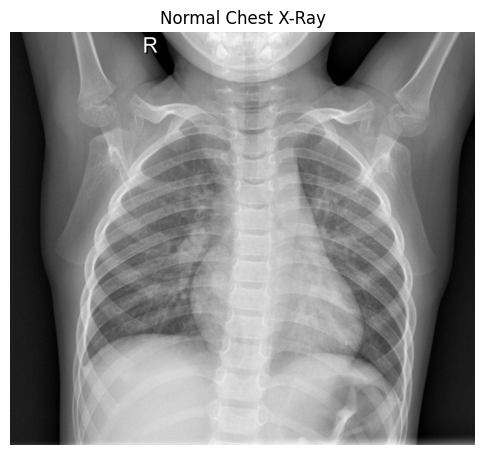

In [10]:
plt.figure(figsize=(6, 6))
plt.imshow(normal_image, cmap="gray")
plt.title("Normal Chest X-Ray")
plt.axis("off")
plt.show()

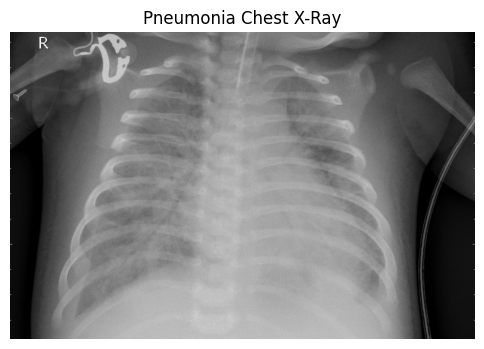

In [11]:
plt.figure(figsize=(6, 6))
plt.imshow(pneumonia_image, cmap="gray")
plt.title("Pneumonia Chest X-Ray")
plt.axis("off")
plt.show()

In [12]:
%pip install torch torchvision

  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Attempting uninstall: setuptools
    Found existing installation: setuptools 57.4.0
    Uninstalling setuptools-57.4.0:
      Successfully uninstalled setuptools-57.4.0
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\ACER\OneDrive\Desktop\ai chatbot\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [13]:
%pip uninstall torch torchvision -y

Found existing installation: torch 2.13.0
Uninstalling torch-2.13.0:
  Successfully uninstalled torch-2.13.0
Found existing installation: torchvision 0.28.0
Uninstalling torchvision-0.28.0:
  Successfully uninstalled torchvision-0.28.0
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install torch==2.8.0 torchvision==0.23.0 --index-url https://download.pytorch.org/whl/cu129

In [ ]:
import sys
print(sys.executable)

c:\Users\ACER\OneDrive\Desktop\ai chatbot\.venv\Scripts\python.exe


In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.8.0+cu129
CUDA build: 12.9
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
%pip install torchvision==0.23.0 --index-url https://download.pytorch.org/whl/cu129

Looking in indexes: https://download.pytorch.org/whl/cu129
  Using cached https://download-r2.pytorch.org/whl/cu129/torchvision-0.23.0%2Bcu129-cp310-cp310-win_amd64.whl (8.1 MB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\ACER\OneDrive\Desktop\ai chatbot\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [4]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

PyTorch: 2.8.0+cu129
Torchvision: 0.23.0+cu129
CUDA: True


In [6]:
import kagglehub

path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print("Dataset path:", path)

c:\Users\ACER\OneDrive\Desktop\ai chatbot\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: C:\Users\ACER\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [7]:
import os

print(os.listdir(path))

['chest_xray']


In [8]:
dataset_path = os.path.join(path, "chest_xray")

print(dataset_path)

C:\Users\ACER\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray


In [9]:
print(os.listdir(dataset_path))

['chest_xray', 'test', 'train', 'val', '__MACOSX']


In [10]:
for split in ["train", "test", "val"]:
    split_path = os.path.join(dataset_path, split)

    print(f"\n{split.upper()}:")
    print(os.listdir(split_path))


TRAIN:
['NORMAL', 'PNEUMONIA']

TEST:
['NORMAL', 'PNEUMONIA']

VAL:
['NORMAL', 'PNEUMONIA']


In [11]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [12]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    os.path.join(dataset_path, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(dataset_path, "val"),
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(dataset_path, "test"),
    transform=test_transform
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Train: 5216
Validation: 16
Test: 624


In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 163
Validation batches: 1
Test batches: 20


In [14]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Image shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([0, 1, 0, 0, 0, 1, 1, 1, 0, 1])


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [16]:
import torch
import torch.nn as nn

class ChestXRayCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [17]:
model = ChestXRayCNN().to(device)

print(model)

ChestXRayCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [18]:
# train the model
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [19]:
import torch

num_epochs = 5

for epoch in range(num_epochs):

    # --------------------
    # Training
    # --------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # --------------------
    # Validation
    # --------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
    )

Epoch [1/5] Train Loss: 0.4022 Train Acc: 81.71% Val Loss: 0.4519 Val Acc: 75.00%
Epoch [2/5] Train Loss: 0.2090 Train Acc: 92.06% Val Loss: 0.5578 Val Acc: 81.25%
Epoch [3/5] Train Loss: 0.1966 Train Acc: 93.16% Val Loss: 0.6075 Val Acc: 68.75%
Epoch [4/5] Train Loss: 0.1722 Train Acc: 94.13% Val Loss: 0.8360 Val Acc: 62.50%
Epoch [5/5] Train Loss: 0.1620 Train Acc: 94.38% Val Loss: 0.7889 Val Acc: 62.50%


In [20]:
import os
import torch

os.makedirs("../model", exist_ok=True)

model_path = "../model/chest_xray_cnn.pth"

torch.save(model.state_dict(), model_path)

print("Model saved at:", model_path)

Model saved at: ../model/chest_xray_cnn.pth


In [21]:
print(os.path.exists(model_path))

True


In [7]:
import os
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# Dataset path
dataset_path = r"C:\Users\ACER\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2\chest_xray"

print("Dataset exists:", os.path.exists(dataset_path))

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Train dataset
full_train = datasets.ImageFolder(
    os.path.join(dataset_path, "train"),
    transform=transform
)

# Validation split
train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size

train_dataset, val_dataset = random_split(
    full_train,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Test dataset
test_dataset = datasets.ImageFolder(
    os.path.join(dataset_path, "test"),
    transform=transform
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("train_loader:", len(train_loader))
print("val_loader:", len(val_loader))
print("test_loader:", len(test_loader))
print("device:", device)

Device: cuda
Dataset exists: True
train_loader: 131
val_loader: 33
test_loader: 20
device: cuda


In [8]:
print("train_loader:", 'train_loader' in globals())
print("val_loader:", 'val_loader' in globals())
print("test_loader:", 'test_loader' in globals())
print("device:", device)

train_loader: True
val_loader: True
test_loader: True
device: cuda


In [9]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

# Pretrained ResNet18
weights = ResNet18_Weights.DEFAULT

model_resnet = resnet18(weights=weights)

# Chest X-ray: 2 classes
model_resnet.fc = nn.Linear(
    model_resnet.fc.in_features,
    2
)

# GPU
model_resnet = model_resnet.to(device)

print(model_resnet.fc)
print("Model device:", next(model_resnet.parameters()).device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ACER/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:34<00:00, 1.38MB/s]


Linear(in_features=512, out_features=2, bias=True)
Model device: cuda:0


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model_resnet.parameters(),
    lr=1e-4
)

print("Loss and optimizer ready")

Loss and optimizer ready


In [11]:
EPOCHS = 5

for epoch in range(EPOCHS):

    model_resnet.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_resnet(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Train Acc: {train_acc:.2f}%"
    )

Epoch [1/5] Loss: 0.1015 Train Acc: 96.24%
Epoch [2/5] Loss: 0.0232 Train Acc: 99.30%
Epoch [3/5] Loss: 0.0173 Train Acc: 99.42%
Epoch [4/5] Loss: 0.0081 Train Acc: 99.81%
Epoch [5/5] Loss: 0.0038 Train Acc: 99.88%


In [12]:
model_resnet.eval()

val_correct = 0
val_total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_resnet(images)

        _, predicted = torch.max(outputs, 1)

        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

val_accuracy = 100 * val_correct / val_total

print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Accuracy: 99.14%


In [13]:
model_resnet.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_resnet(images)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(
            predictions.cpu().numpy()
        )

print("Test prediction completed.")

Test prediction completed.


In [14]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

Test Accuracy: 77.72%

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.99      0.41      0.58       234
   PNEUMONIA       0.74      1.00      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.70      0.71       624
weighted avg       0.83      0.78      0.75       624



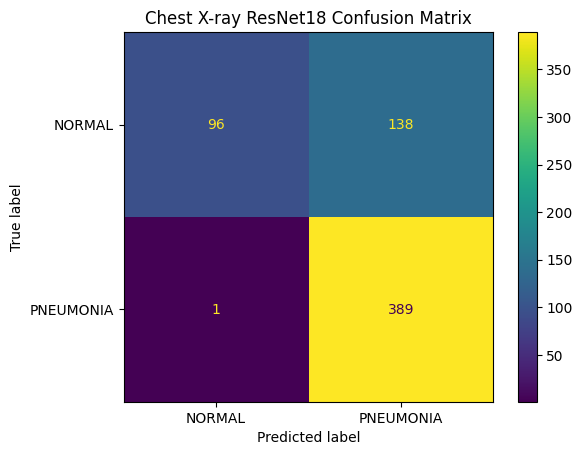

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot()

plt.title("Chest X-ray ResNet18 Confusion Matrix")
plt.show()

In [16]:
import os

os.makedirs("models", exist_ok=True)

resnet_path = "models/chest_xray_resnet18.pth"

torch.save(
    model_resnet.state_dict(),
    resnet_path
)

print("ResNet model saved:", resnet_path)

ResNet model saved: models/chest_xray_resnet18.pth


In [17]:
print(os.path.exists(resnet_path))

True


In [18]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [19]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

model_resnet = resnet18(weights=None)

model_resnet.fc = nn.Linear(
    model_resnet.fc.in_features,
    2
)

model_resnet.load_state_dict(
    torch.load(
        "models/chest_xray_resnet18.pth",
        map_location=device
    )
)

model_resnet = model_resnet.to(device)
model_resnet.eval()

print("ResNet loaded successfully")

ResNet loaded successfully


In [20]:
target_layers = [
    model_resnet.layer4[-1]
]

In [21]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [22]:
def predict_with_gradcam(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Resize for display
    display_image = image.resize((224, 224))

    # Convert to numpy 0-1
    rgb_image = np.array(
        display_image
    ).astype(np.float32) / 255.0

    # Model input
    input_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    # Prediction
    model_resnet.eval()

    output = model_resnet(
        input_tensor
    )

    probabilities = torch.softmax(
        output,
        dim=1
    )

    predicted_class = output.argmax(
        dim=1
    ).item()

    confidence = probabilities[
        0, predicted_class
    ].item()

    # Grad-CAM
    cam = GradCAM(
        model=model_resnet,
        target_layers=target_layers
    )

    targets = [
        ClassifierOutputTarget(
            predicted_class
        )
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    # Heatmap overlay
    visualization = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    return (
        predicted_class,
        confidence,
        visualization,
        rgb_image
    )

In [23]:
image_path = r"C:\ai chatbot\assets\test_images\my_xray.jpg"

In [26]:
import os
from PIL import Image
import matplotlib.pyplot as plt

print("Current folder:", os.getcwd())

for root, dirs, files in os.walk(r"C:\ai chatbot"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            print(os.path.join(root, file))

Current folder: c:\ai chatbot\notebooks
C:\ai chatbot\.venv\Lib\site-packages\ipykernel\resources\logo-32x32.png
C:\ai chatbot\.venv\Lib\site-packages\ipykernel\resources\logo-64x64.png
C:\ai chatbot\.venv\Lib\site-packages\IPython\core\tests\2x2.jpg
C:\ai chatbot\.venv\Lib\site-packages\IPython\core\tests\2x2.png
C:\ai chatbot\.venv\Lib\site-packages\matplotlib\mpl-data\images\back.png
C:\ai chatbot\.venv\Lib\site-packages\matplotlib\mpl-data\images\back_large.png
C:\ai chatbot\.venv\Lib\site-packages\matplotlib\mpl-data\images\filesave.png
C:\ai chatbot\.venv\Lib\site-packages\matplotlib\mpl-data\images\filesave_large.png
C:\ai chatbot\.venv\Lib\site-packages\matplotlib\mpl-data\images\forward.png
C:\ai chatbot\.venv\Lib\site-packages\matplotlib\mpl-data\images\forward_large.png
C:\ai chatbot\.venv\Lib\site-packages\matplotlib\mpl-data\images\hand.png
C:\ai chatbot\.venv\Lib\site-packages\matplotlib\mpl-data\images\help.png
C:\ai chatbot\.venv\Lib\site-packages\matplotlib\mpl-data\im

Image exists: True


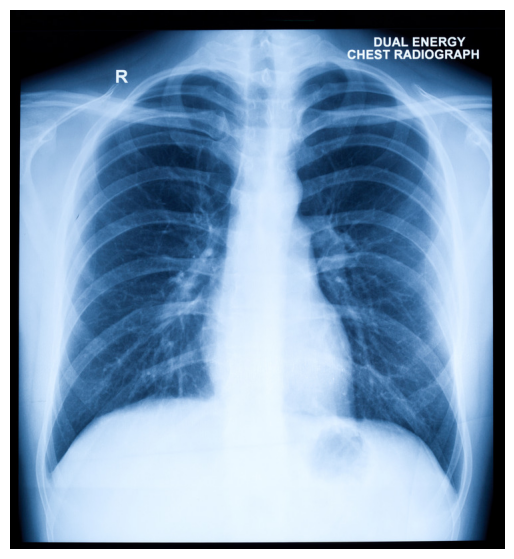

In [27]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_path = r"../assets/test_images/R.jpg"

print("Image exists:", os.path.exists(image_path))

image = Image.open(image_path)

plt.figure(figsize=(7, 7))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [28]:
predicted_class, confidence, heatmap, original = predict_with_gradcam(
    image_path
)

class_names = test_dataset.classes

prediction = class_names[predicted_class]

print("Prediction:", prediction)
print(f"Confidence: {confidence * 100:.2f}%")

Prediction: PNEUMONIA
Confidence: 86.27%


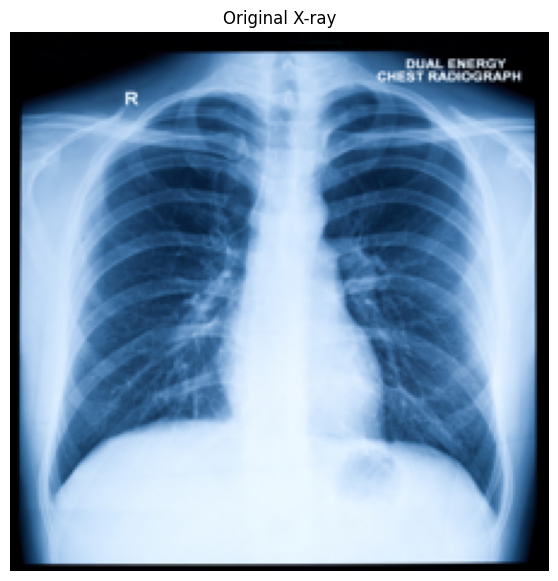

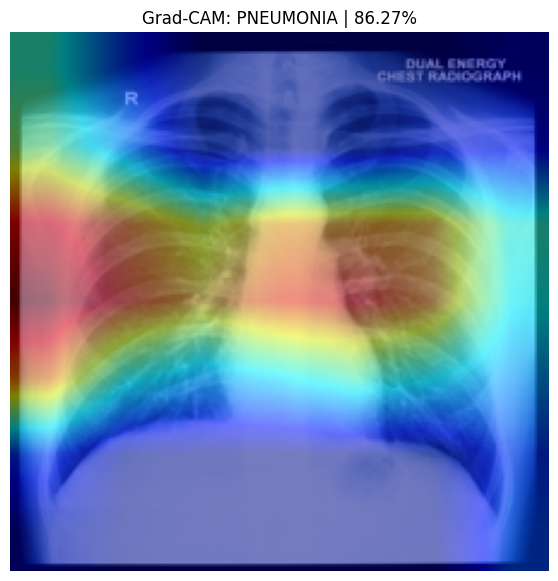

In [29]:
plt.figure(figsize=(7, 7))

plt.imshow(original)
plt.axis("off")
plt.title("Original X-ray")
plt.show()

plt.figure(figsize=(7, 7))

plt.imshow(heatmap)
plt.axis("off")
plt.title(
    f"Grad-CAM: {prediction} | "
    f"{confidence * 100:.2f}%"
)
plt.show()

In [30]:
os.makedirs("results", exist_ok=True)

save_path = "results/chest_xray_gradcam.jpg"

cv2.imwrite(
    save_path,
    cv2.cvtColor(heatmap, cv2.COLOR_RGB2BGR)
)

print("Saved:", save_path)

Saved: results/chest_xray_gradcam.jpg


In [34]:
print("Image exists:", IMAGE_PATH.exists())
print("ResNet exists:", RESNET_MODEL_PATH.exists())
print("Device:", device)

Image exists: True
ResNet exists: False
Device: cuda


In [35]:
from pathlib import Path

project_root = Path(r"C:\ai chatbot")

matches = list(project_root.glob("**/chest_xray_resnet18.pth"))

print("Found files:")

for file in matches:
    print(file)

Found files:
C:\ai chatbot\notebooks\models\chest_xray_resnet18.pth


In [36]:
from pathlib import Path
import shutil

PROJECT_ROOT = Path(r"C:\ai chatbot")

old_path = PROJECT_ROOT / "notebooks" / "models" / "chest_xray_resnet18.pth"
new_dir = PROJECT_ROOT / "model"
new_dir.mkdir(exist_ok=True)

new_path = new_dir / "chest_xray_resnet18.pth"

shutil.copy2(old_path, new_path)

print("Old:", old_path)
print("New:", new_path)
print("New file exists:", new_path.exists())

Old: C:\ai chatbot\notebooks\models\chest_xray_resnet18.pth
New: C:\ai chatbot\model\chest_xray_resnet18.pth
New file exists: True


In [37]:
RESNET_MODEL_PATH = Path(
    r"C:\ai chatbot\model\chest_xray_resnet18.pth"
)

print(RESNET_MODEL_PATH)
print("ResNet exists:", RESNET_MODEL_PATH.exists())

C:\ai chatbot\model\chest_xray_resnet18.pth
ResNet exists: True


In [38]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\ai chatbot")

IMAGE_PATH = PROJECT_ROOT / "assets" / "test_images" / "R.jpg"
RESNET_MODEL_PATH = PROJECT_ROOT / "model" / "chest_xray_resnet18.pth"

print("Image:", IMAGE_PATH.exists())
print("ResNet:", RESNET_MODEL_PATH.exists())

Image: True
ResNet: True


In [39]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_resnet = resnet18(weights=None)

model_resnet.fc = nn.Linear(
    model_resnet.fc.in_features,
    2
)

model_resnet.load_state_dict(
    torch.load(
        RESNET_MODEL_PATH,
        map_location=device
    )
)

model_resnet = model_resnet.to(device)
model_resnet.eval()

print("ResNet loaded")
print("Device:", device)

ResNet loaded
Device: cuda


In [40]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [41]:
target_layers = [
    model_resnet.layer4[-1]
]

In [42]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_with_gradcam(image_path):

    image = Image.open(image_path).convert("RGB")

    display_image = image.resize((224, 224))

    rgb_image = np.array(
        display_image
    ).astype(np.float32) / 255.0

    input_tensor = transform(
        image
    ).unsqueeze(0).to(device)

    output = model_resnet(input_tensor)

    probabilities = torch.softmax(output, dim=1)

    predicted_class = output.argmax(dim=1).item()

    confidence = probabilities[
        0, predicted_class
    ].item()

    cam = GradCAM(
        model=model_resnet,
        target_layers=target_layers
    )

    targets = [
        ClassifierOutputTarget(predicted_class)
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    heatmap = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )


    return predicted_class, confidence, heatmap, rgb_image

In [43]:
predicted_class, confidence, heatmap, original = predict_with_gradcam(
    IMAGE_PATH
)

class_names = test_dataset.classes

prediction = class_names[predicted_class]

print("Prediction:", prediction)
print(f"Confidence: {confidence * 100:.2f}%")

Prediction: PNEUMONIA
Confidence: 86.27%


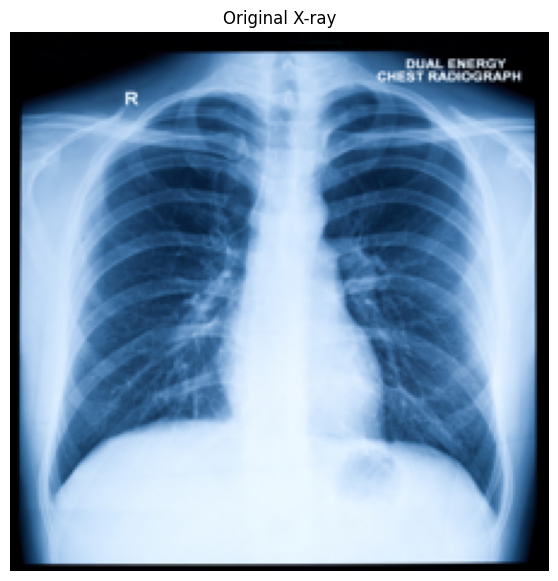

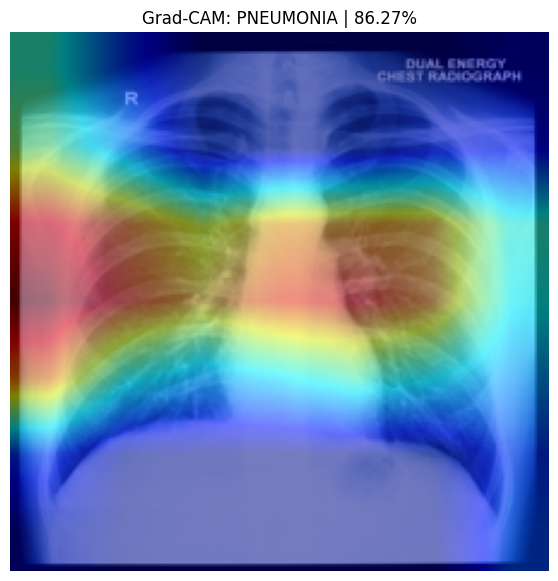

In [44]:
plt.figure(figsize=(7, 7))
plt.imshow(original)
plt.axis("off")
plt.title("Original X-ray")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(heatmap)
plt.axis("off")
plt.title(
    f"Grad-CAM: {prediction} | {confidence * 100:.2f}%"
)
plt.show()